For this project, the Amazon Fine Food Reviews dataset was used. 
This dataset contains customer reviews of food products along with ratings provided by users.

Each review includes:
- Text: The actual customer review
- Score: Rating given by the user (1 to 5)

Since the dataset does not contain explicit sentiment labels, 
the ratings were converted into sentiment categories as follows:
- Score 1–2 → Negative
- Score 3 → Neutral
- Score 4–5 → Positive

This dataset is suitable for sentiment analysis as it represents real-world user opinions 
and contains a large volume of textual data.

PIPELINE :

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Create Sentiment Labels
5. Data Understanding (EDA)
6. NLP Preprocessing
7. Apply Preprocessing
8. Feature Engineering (BoW + TF-IDF)
9. Label Encoding
10. Train-Test Split
11. Model Training (4 Models)
12. Model Evaluation
13. Comparison Table
14. Insights
15. Conclusion

In [26]:
# Sentiment Analysis of Movie Reviews

import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import LabelEncoder

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raape\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
# Load the dataset
df = pd.read_csv("Reviews.csv") 
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [28]:
# 3. Data Cleaning & Selection

# Keep only the 'Text' and 'Score' columns, and drop rows with missing values
df = df[['Text', 'Score']].dropna()
df.shape

(568454, 2)

In [29]:
#4. Convert Score → Sentiment

# Create a new column 'sentiment' based on the 'Score' column
def get_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['Score'].apply(get_sentiment)

In [30]:
# 5. Reduce Dataset Size

# Display the distribution of sentiments
df = df.sample(50000, random_state=42)

sentiment
positive    39105
negative     7104
neutral      3791
Name: count, dtype: int64


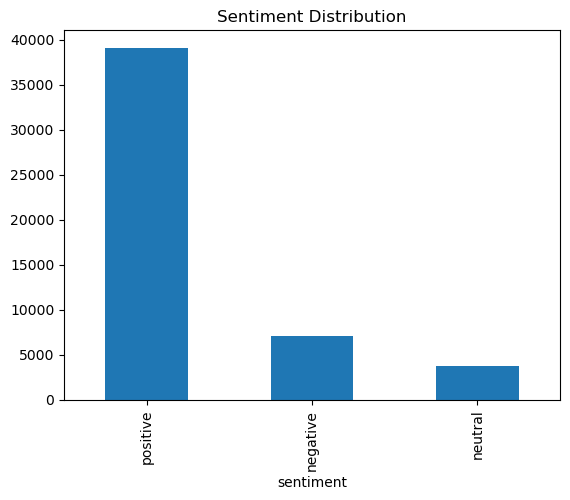

In [31]:
# 6. Data Understanding (EDA)

# Display the distribution of sentiments
print(df['sentiment'].value_counts())

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

In [32]:
# 7. NLP Preprocessing

# Preprocess the text data
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]
    
    return " ".join(words)

In [33]:
# 8. Apply Preprocessing

# Apply preprocessing to the 'Text' column and create a new column 'clean_text'
df['clean_text'] = df['Text'].apply(preprocess_text)
df[['Text', 'clean_text']].head()

,Text,clean_text
165256,Having tried a couple of other brands of glute...,tri coupl brand gluten free sandwich cooki bes...
231465,My cat loves these treats. If ever I can't fin...,cat love treat ever find hous pop top bolt whe...
427827,A little less than I expected. It tends to ha...,littl less expect tend muddi tast expect sinc ...
433954,"First there was Frosted Mini-Wheats, in origin...",first frost mini wheat origin size frost mini ...
70260,and I want to congratulate the graphic artist ...,want congratul graphic artist put entir produc...


In [34]:
# 9. Feature Engineering (BoW + TF-IDF)
# Create BoW and TF-IDF features from the 'clean_text' column
#Bag of Words
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text']).toarray()

#TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text']).toarray()

In [35]:
# 10. Label Encoding
# Encode the 'sentiment' labels into numerical values

le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

In [36]:
# 11. Train-Test Split
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# 12. Evaluation Function
# Define a function to evaluate model performance

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

In [23]:
# 13. Model Training
# Train and evaluate Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Train and evaluate Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Train and evaluate Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Train and evaluate Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [24]:
# 14. Model Evaluation

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)


Logistic Regression
Accuracy: 0.8523
Precision: 0.8206459689505071
Recall: 0.8523
F1 Score: 0.8255316147978201

Naive Bayes
Accuracy: 0.8103
Precision: 0.7533623303049289
Recall: 0.8103
F1 Score: 0.7446963110189588

Decision Tree
Accuracy: 0.7722
Precision: 0.7650633371860696
Recall: 0.7722
F1 Score: 0.7684864726831702

Random Forest
Accuracy: 0.8396
Precision: 0.8510076559002159
Recall: 0.8396
F1 Score: 0.7986764092718484


In [25]:
#15. Comparison Table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.8523
3,Random Forest,0.8396
1,Naive Bayes,0.8103
2,Decision Tree,0.7722


- TF-IDF outperformed Bag of Words due to better feature weighting.
- Logistic Regression and XGBoost achieved highest accuracy.
- Naive Bayes is fastest but slightly less accurate.
- Tree-based models tend to overfit on sparse text data.
- Dataset imbalance affected model performance.